FIRST 5 RECORDS
  Customer_ID  Gender  Senior_Citizen Partner Dependents  Tenure_Months  \
0   CUST10001    Male               0      No         No             52   
1   CUST10002  Female               1      No         No             68   
2   CUST10003    Male               0      No         No             13   
3   CUST10004    Male               0     Yes         No             72   
4   CUST10005    Male               0     Yes         No             14   

  Phone_Service Multiple_Lines Internet_Service      Online_Security  ...  \
0           Yes            Yes              DSL                  Yes  ...   
1           Yes             No               No  No internet service  ...   
2           Yes            Yes      Fiber optic                  Yes  ...   
3           Yes            Yes               No  No internet service  ...   
4           Yes            Yes               No  No internet service  ...   

          Tech_Support         Streaming_TV     Streaming_Movies  Cont

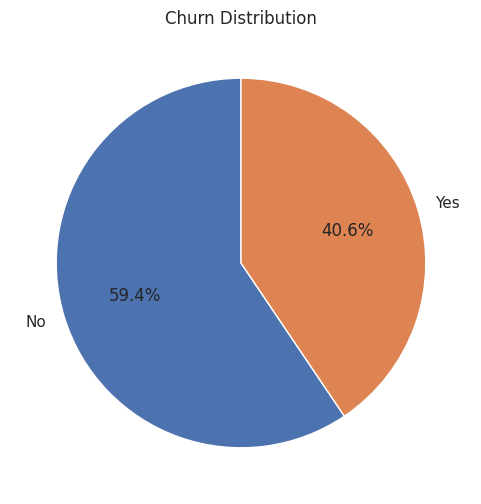

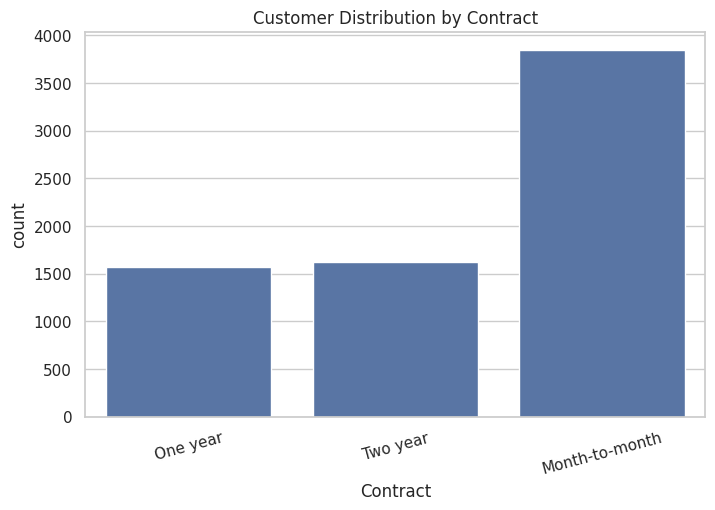

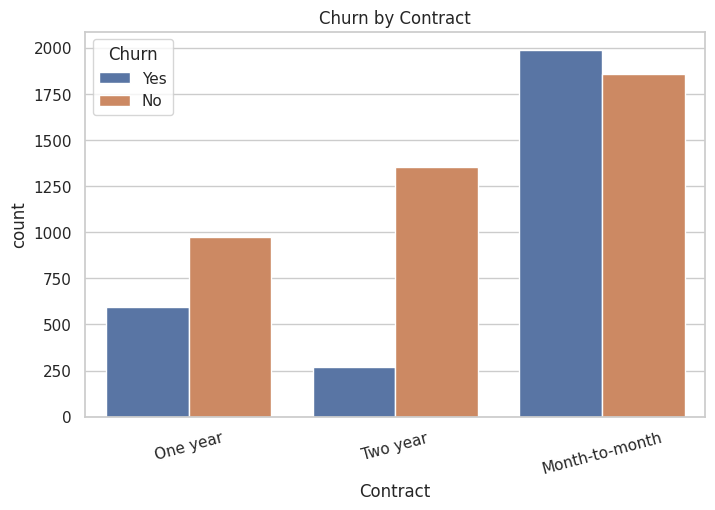

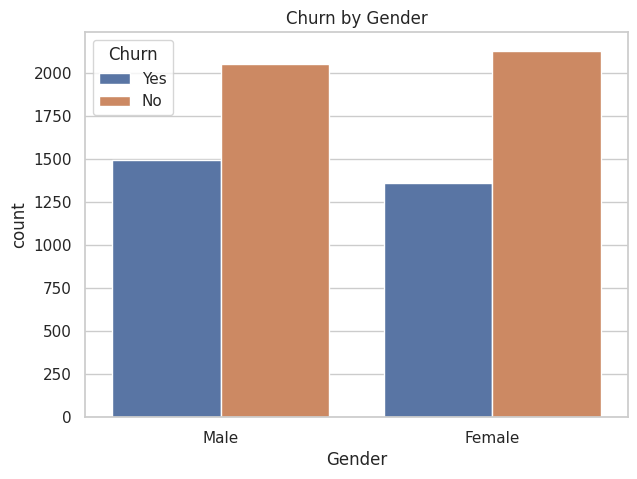

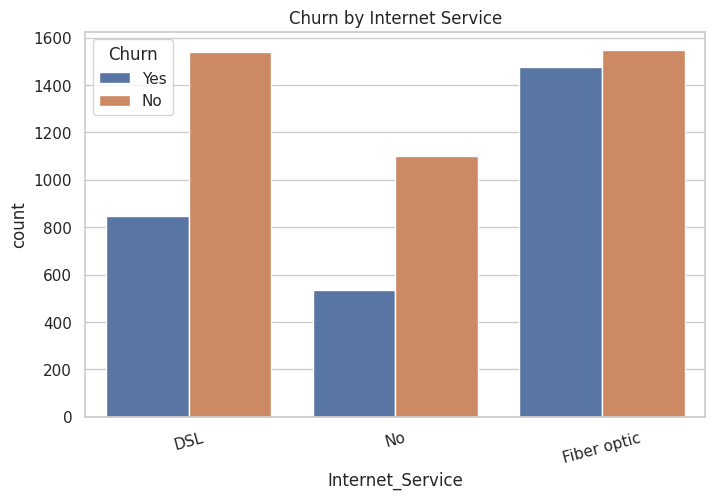

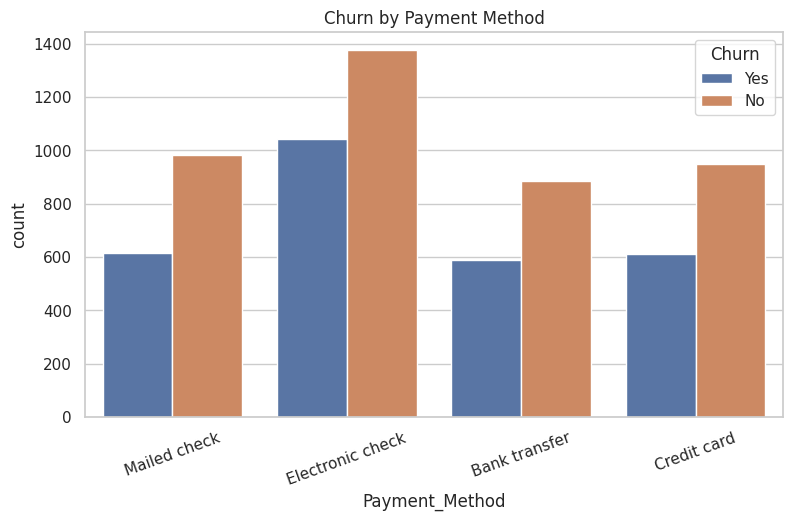

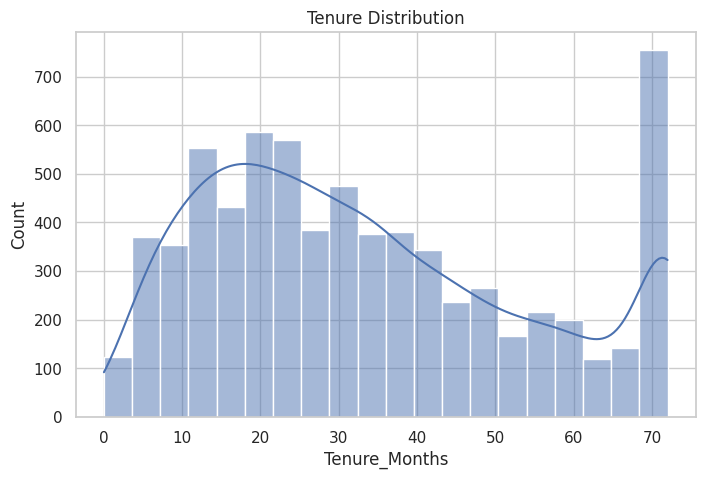

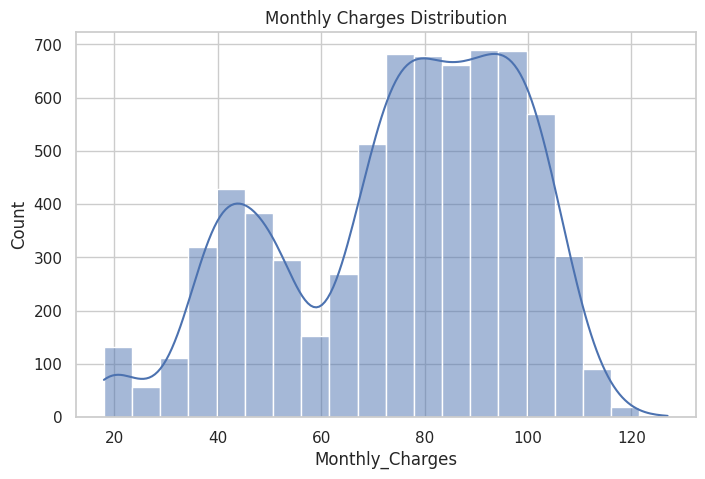

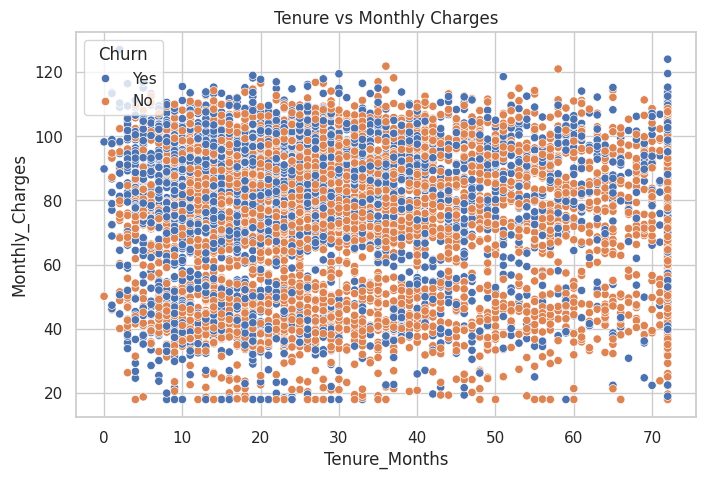

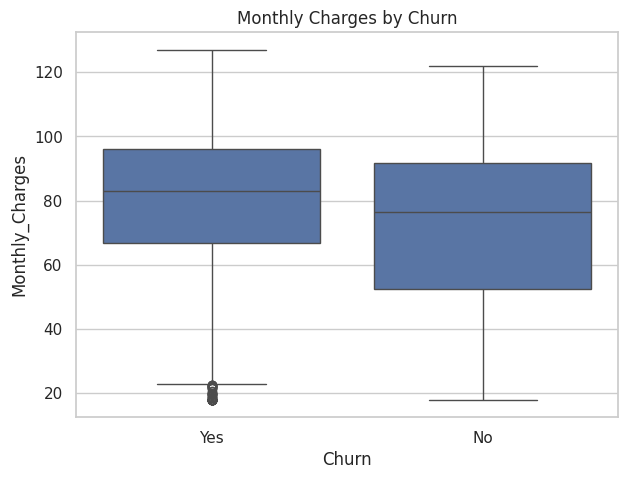

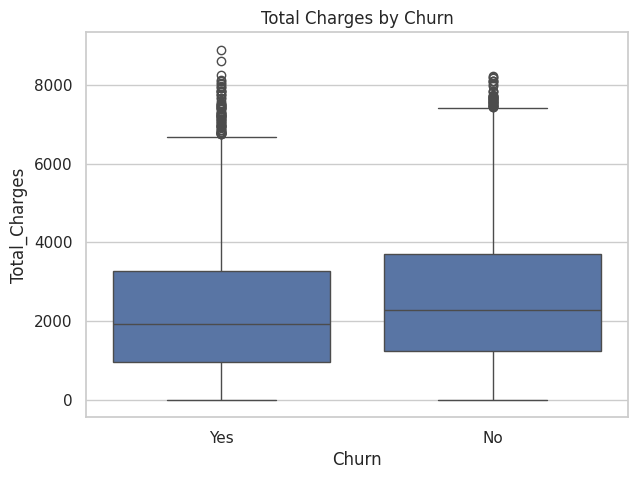

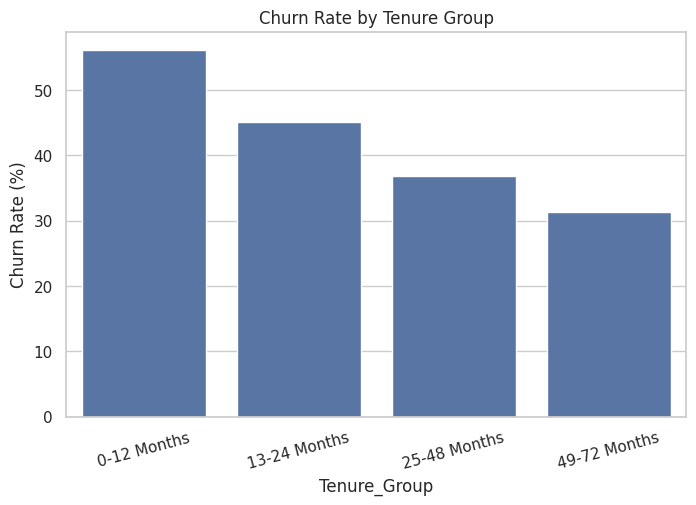

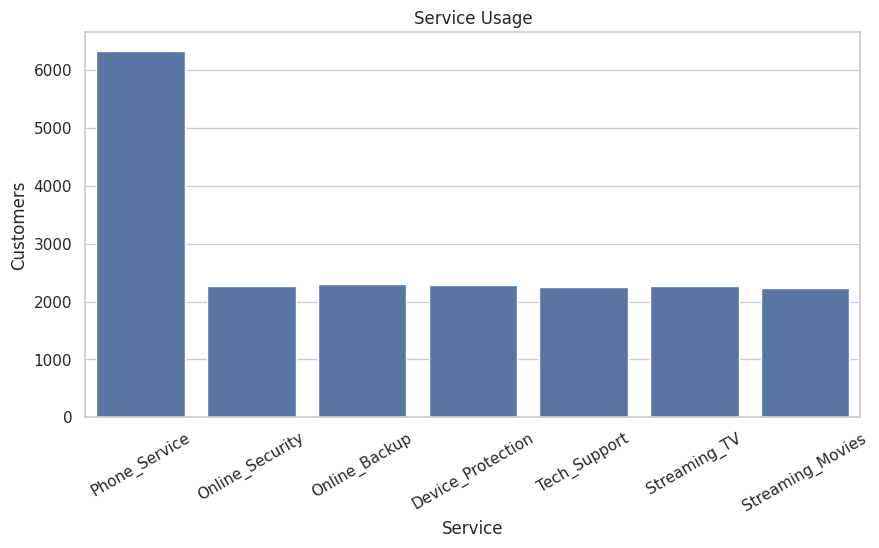

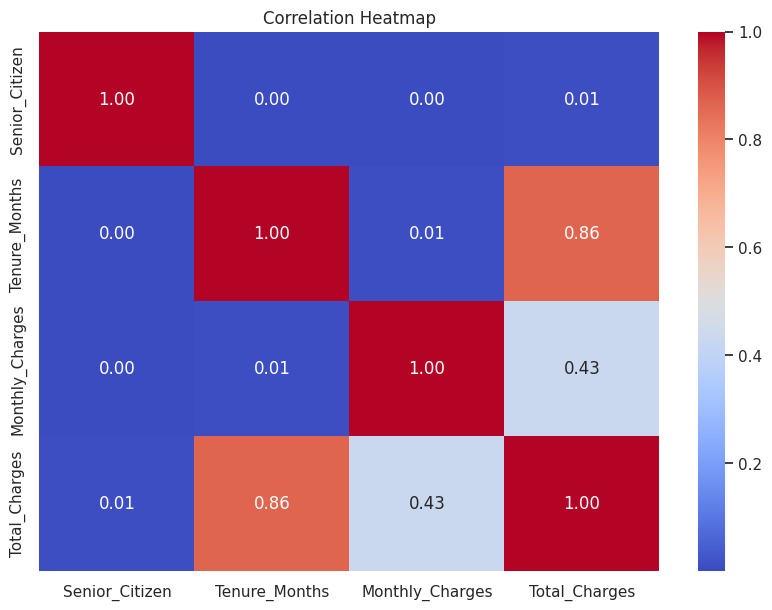


PROJECT COMPLETED SUCCESSFULLY!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# PART 1 - DATA LOADING
# ============================================================

df = pd.read_csv("Customer_Churn_Cleaned.csv")

print("FIRST 5 RECORDS")
print(df.head())

print("\nLAST 5 RECORDS")
print(df.tail())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns.tolist())

# ============================================================
# PART 2 - DATA EXPLORATION & CLEANING
# ============================================================

print("\nDATA TYPES")
print(df.dtypes)

print("\nSTATISTICAL INFORMATION")
print(df.describe(include="all"))

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATE RECORDS")
print(df.duplicated().sum())

# Remove duplicate records
df = df.drop_duplicates()

print("\nUNIQUE VALUES")
for col in df.columns:
    print("\n", col)
    print(df[col].unique()[:10])

# Convert numeric columns
df["Monthly_Charges"] = pd.to_numeric(df["Monthly_Charges"], errors="coerce")
df["Total_Charges"] = pd.to_numeric(df["Total_Charges"], errors="coerce")

# Fill missing numeric values with median
numeric_columns = df.select_dtypes(include="number").columns
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with mode
categorical_columns = df.select_dtypes(include="object").columns
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Make sure Senior_Citizen is integer
df["Senior_Citizen"] = df["Senior_Citizen"].astype(int)

# Create tenure groups
df["Tenure_Group"] = pd.cut(
    df["Tenure_Months"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"]
)

print("\nCLEANED DATASET")
print(df.head())

print("\nCLEANED SHAPE")
print(df.shape)

print("\nMISSING VALUES AFTER CLEANING")
print(df.isnull().sum())

# Save cleaned CSV
df.to_csv("Customer_Churn_Cleaned.csv", index=False)

# ============================================================
# PART 3 - DATA ANALYSIS
# ============================================================

total_customers = df["Customer_ID"].nunique()
churned_customers = (df["Churn"] == "Yes").sum()
retained_customers = (df["Churn"] == "No").sum()
churn_rate = (churned_customers / total_customers) * 100

avg_monthly_charges = df["Monthly_Charges"].mean()
avg_total_charges = df["Total_Charges"].mean()
avg_tenure = df["Tenure_Months"].mean()

print("\n========== KEY KPIs ==========")
print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Overall Churn Rate:", round(churn_rate, 2), "%")
print("Average Monthly Charges:", round(avg_monthly_charges, 2))
print("Average Total Charges:", round(avg_total_charges, 2))
print("Average Tenure:", round(avg_tenure, 2), "months")

print("\nCUSTOMERS BY GENDER")
print(df["Gender"].value_counts())

print("\nCUSTOMERS BY CONTRACT")
print(df["Contract"].value_counts())

print("\nCUSTOMERS BY INTERNET SERVICE")
print(df["Internet_Service"].value_counts())

print("\nCUSTOMERS BY PAYMENT METHOD")
print(df["Payment_Method"].value_counts())

print("\nCHURN RATE BY GENDER")
print(df.groupby("Gender")["Churn"].apply(lambda x: (x == "Yes").mean() * 100).round(2))

print("\nCHURN RATE BY CONTRACT")
print(df.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean() * 100).round(2))

print("\nCHURN RATE BY INTERNET SERVICE")
print(df.groupby("Internet_Service")["Churn"].apply(lambda x: (x == "Yes").mean() * 100).round(2))

print("\nCHURN RATE BY PAYMENT METHOD")
print(df.groupby("Payment_Method")["Churn"].apply(lambda x: (x == "Yes").mean() * 100).round(2))

print("\nCHURN RATE BY SENIOR CITIZEN STATUS")
print(df.groupby("Senior_Citizen")["Churn"].apply(lambda x: (x == "Yes").mean() * 100).round(2))

print("\nCHURN RATE BY TENURE GROUP")
print(df.groupby("Tenure_Group", observed=False)["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
).round(2))

print("\nMONTHLY CHARGES - CHURNED VS RETAINED")
print(df.groupby("Churn")["Monthly_Charges"].mean().round(2))

print("\nTENURE - CHURNED VS RETAINED")
print(df.groupby("Churn")["Tenure_Months"].mean().round(2))

print("\nTOP 10 CUSTOMERS BY TOTAL CHARGES")
print(df.nlargest(10, "Total_Charges")[
    ["Customer_ID", "Contract", "Tenure_Months", "Monthly_Charges", "Total_Charges", "Churn"]
])

print("\nCHURN SEGMENTS")
segment = df.groupby(["Contract", "Internet_Service"], observed=False)["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
).sort_values(ascending=False)
print(segment.head(10).round(2))

# ============================================================
# PART 4 - PYTHON VISUALIZATIONS
# ============================================================

sns.set_theme(style="whitegrid")

# 1. Churn Distribution - Pie Chart
plt.figure(figsize=(6, 6))
df["Churn"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90)
plt.title("Churn Distribution")
plt.ylabel("")
plt.show()

# 2. Customer Distribution by Contract - Bar Chart
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract")
plt.title("Customer Distribution by Contract")
plt.xticks(rotation=15)
plt.show()

# 3. Churn by Contract
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract")
plt.xticks(rotation=15)
plt.show()

# 4. Churn by Gender
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Gender", hue="Churn")
plt.title("Churn by Gender")
plt.show()

# 5. Churn by Internet Service
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Internet_Service", hue="Churn")
plt.title("Churn by Internet Service")
plt.xticks(rotation=15)
plt.show()

# 6. Churn by Payment Method
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="Payment_Method", hue="Churn")
plt.title("Churn by Payment Method")
plt.xticks(rotation=20)
plt.show()

# 7. Tenure Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Tenure_Months", bins=20, kde=True)
plt.title("Tenure Distribution")
plt.show()

# 8. Monthly Charges Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Monthly_Charges", bins=20, kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

# 9. Tenure vs Monthly Charges
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Tenure_Months", y="Monthly_Charges", hue="Churn")
plt.title("Tenure vs Monthly Charges")
plt.show()

# 10. Monthly Charges by Churn
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Churn", y="Monthly_Charges")
plt.title("Monthly Charges by Churn")
plt.show()

# 11. Total Charges by Churn
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Churn", y="Total_Charges")
plt.title("Total Charges by Churn")
plt.show()

# 12. Churn Rate by Tenure Group
tenure_churn = df.groupby("Tenure_Group", observed=False)["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
).reset_index(name="Churn_Rate")

plt.figure(figsize=(8, 5))
sns.barplot(data=tenure_churn, x="Tenure_Group", y="Churn_Rate")
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.show()

# 13. Service Usage - Count Plot
service_cols = [
    "Phone_Service", "Online_Security", "Online_Backup",
    "Device_Protection", "Tech_Support", "Streaming_TV",
    "Streaming_Movies"
]

service_counts = {}
for col in service_cols:
    service_counts[col] = (df[col] == "Yes").sum()

service_df = pd.DataFrame({
    "Service": list(service_counts.keys()),
    "Customers": list(service_counts.values())
})

plt.figure(figsize=(10, 5))
sns.barplot(data=service_df, x="Service", y="Customers")
plt.title("Service Usage")
plt.xticks(rotation=30)
plt.show()
# 14. Correlation Heatmap
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

print("\nPROJECT COMPLETED SUCCESSFULLY!")
